## Section 1: The Configuration & Environment Setup
*We centralize all hyperparameters here. This makes Ablation Studies easy. We also initialize our GPU and import required libraries.*

In [9]:
import os
import torch
import numpy as np
import random
import wandb
from google.colab import drive
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# --- THE CONTROL PANEL ---
CONFIG = {
    "epochs": 200,
    "batch_size": 128,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "n_points": 1024,
    "num_classes": 40,
    "use_weighted_loss": True, # Set to True for this notebook!
    "run_name": "pointnet-weighted-200ep-smooth0.1"
}

# Setup GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Section 2: Data Extraction
*Mount Google Drive and extract the ZIP file to the fast local Colab storage (`/content/data`) to prevent I/O bottlenecks.*

In [2]:
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
zip_path = '/content/drive/MyDrive/Colab Notebooks/AI535_Final_Project/ModelNet40.zip'
local_extract_path = '/content/data'
root_dir = os.path.join(local_extract_path, 'ModelNet40')

# 3. Extract if not already extracted in this session
if not os.path.exists(root_dir):
    print("Extracting ModelNet40 to local Colab storage. This may take a minute...")
    !unzip -q "{zip_path}" -d {local_extract_path}
    print("Extraction complete!")
else:
    print("Data is already extracted and ready to go.")

Mounted at /content/drive
Extracting ModelNet40 to local Colab storage. This may take a minute...
Extraction complete!


## Section 3: High-RAM Dataset Loading & Class Weight Calculation
*Parse the 3D objects, cache them in RAM, and mathematically calculate the inverse class frequencies to handle ModelNet40's severe class imbalance.*

In [3]:
# Dynamically map the 40 classes
classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

def load_off(file_path, n_points=1024):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    if lines[0].strip() == 'OFF':
        n_verts = int(lines[1].strip().split()[0])
        verts_start = 2
    else:
        n_verts = int(lines[0].strip()[3:].split()[0])
        verts_start = 1

    verts = np.array([ [float(x) for x in l.strip().split()] for l in lines[verts_start:verts_start + n_verts] ])

    if len(verts) >= n_points:
        indices = np.random.choice(len(verts), n_points, replace=False)
    else:
        indices = np.random.choice(len(verts), n_points, replace=True)
    verts = verts[indices]

    # Normalization
    verts = verts - np.mean(verts, axis=0)
    dist = np.max(np.sqrt(np.sum(verts**2, axis=1)))
    verts = verts / dist

    return torch.tensor(verts, dtype=torch.float32)

class FastModelNetDataset(Dataset):
    def __init__(self, root, split='train', n_points=1024):
        self.n_points = n_points
        self.files = []
        for cls_name, idx in class_to_idx.items():
            cls_folder = os.path.join(root, cls_name, split)
            if os.path.exists(cls_folder):
                for f in os.listdir(cls_folder):
                    if f.endswith('.off'):
                        self.files.append({'path': os.path.join(cls_folder, f), 'label': idx})

        print(f"Parsing and caching {len(self.files)} {split} files into RAM...")
        self.data = []
        self.labels = []
        for item in self.files:
            points = load_off(item['path'], self.n_points)
            self.data.append(points.transpose(0, 1))
            self.labels.append(item['label'])
        print(f"Finished caching {split} split!")

    def __len__(self): return len(self.files)
    def __getitem__(self, idx): return self.data[idx], self.labels[idx]

# Initialize Datasets
trainset = FastModelNetDataset(root_dir, split='train', n_points=CONFIG["n_points"])
testset = FastModelNetDataset(root_dir, split='test', n_points=CONFIG["n_points"])

trainloader = DataLoader(trainset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

# --- CLASS IMBALANCE CALCULATION ---
print("\nCalculating class weights for Weighted Cross-Entropy...")
class_counts = np.zeros(CONFIG["num_classes"])
for label in trainset.labels:
    class_counts[label] += 1

# w_c = N_total / (C * N_c)
total_samples = len(trainset.labels)
class_weights = total_samples / (CONFIG["num_classes"] * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights calculated successfully!")

Parsing and caching 9843 train files into RAM...
Finished caching train split!
Parsing and caching 2468 test files into RAM...
Finished caching test split!

Calculating class weights for Weighted Cross-Entropy...
Class weights calculated successfully!


## Section 4: PointNet Architecture
*Defines the Spatial Deep Network using Shared MLPs and Global Max Pooling to achieve permutation invariance.*

In [10]:
class PointNet(nn.Module):
    def __init__(self, num_classes=40):
        super(PointNet, self).__init__()

        # Shared MLPs
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)

        # Classification Head
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        # Feature Extraction
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        # Symmetric Function: Global Max Pooling
        x = torch.max(x, 2)[0]

        # Classification
        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(self.dropout(x))))
        out = self.fc3(x)
        return out

model = PointNet(num_classes=CONFIG["num_classes"]).to(device)
print("PointNet initialized!")

PointNet initialized!


## Section 5: Training Loop with Early Stopping
*Trains the model using AdamW and Cosine Annealing. Implements checkpointing to save the best model weights before overfitting occurs.*

In [1]:
wandb.login()
wandb.init(project="ai535-final-project", name=CONFIG["run_name"], config=CONFIG)

# --- APPLY WEIGHTED LOSS IF CONFIGURED ---
if CONFIG["use_weighted_loss"]:
    print("Using WEIGHTED Cross-Entropy Loss with Label Smoothing")
    ccriterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
else:
    print("Using STANDARD Cross-Entropy Loss")
    criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

wandb.watch(model, criterion, log="all", log_freq=10)

best_test_error = 100.0
save_path = '/content/drive/MyDrive/Colab Notebooks/AI535_Final_Project/best_weighted_pointnet.pth'

print(f"Start Training for {CONFIG['epochs']} Epochs...")

for epoch in range(CONFIG["epochs"]):
    model.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    avg_train_loss = running_loss / len(trainset)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # Evaluation phase
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_test_loss = test_loss / len(testset)
    test_error = 100.0 * (1 - correct / total)

    wandb.log({
        "Epoch": epoch + 1,
        "Training Loss": avg_train_loss,
        "Testing Loss": avg_test_loss,
        "Testing Error (%)": test_error,
        "Learning Rate": current_lr
    })

    # --- EARLY STOPPING CHECKPOINTING ---
    if test_error < best_test_error:
        best_test_error = test_error
        torch.save(model.state_dict(), save_path)
        checkpoint_msg = f"** New Best! Saved to Drive **"
    else:
        checkpoint_msg = ""

    print(f"Epoch [{epoch+1}/{CONFIG['epochs']}] - Train Loss: {avg_train_loss:.4f} | Test Error: {test_error:.2f}% | {checkpoint_msg}")

print(f"Finished Training! Best Test Error was {best_test_error:.2f}%")
wandb.finish()

NameError: name 'wandb' is not defined

## Section 6: Quantitative Evaluation (OA & mAcc)
*Loads the best saved weights and calculates Overall Accuracy and Mean Per-Class Accuracy to prove the effectiveness of the Weighted Loss.*

In [6]:
# 1. Surgically remove W&B hooks
for module in model.modules():
    module._forward_hooks.clear()
    module._backward_hooks.clear()
    module._forward_pre_hooks.clear()

# 2. Load the BEST weights from our checkpoint
model.load_state_dict(torch.load(save_path))
model.eval()

total, correct = 0, 0
class_correct = torch.zeros(40).to(device)
class_total = torch.zeros(40).to(device)

print("Evaluating Best Checkpoint on Test Set...")

with torch.no_grad():
    for points, labels in testloader:
        points, labels = points.to(device), labels.to(device)
        outputs = model(points)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        c = (predicted == labels)
        for i in range(labels.size(0)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

oa = 100.0 * correct / total
per_class_acc = class_correct / torch.clamp(class_total, min=1)
macc = 100.0 * torch.mean(per_class_acc).item()

print("-" * 30)
print(f"Final Overall Accuracy (OA):       {oa:.2f}%")
print(f"Final Mean Per-Class Acc (mAcc):   {macc:.2f}%")
print("-" * 30)

print("\nLowest performing classes:")
acc_dict = {classes[i]: (per_class_acc[i].item() * 100) for i in range(40)}
sorted_acc = sorted(acc_dict.items(), key=lambda x: x[1])
for cls_name, acc in sorted_acc[:5]:
    print(f"{cls_name:>15}: {acc:.2f}%")

Evaluating Best Checkpoint on Test Set...
------------------------------
Final Overall Accuracy (OA):       84.16%
Final Mean Per-Class Acc (mAcc):   79.30%
------------------------------

Lowest performing classes:
     flower_pot: 10.00%
            cup: 50.00%
          radio: 55.00%
           lamp: 60.00%
          stool: 60.00%


## Section 7: Qualitative Results (10-Class Visualization Grid)
*Generates a 3D scatter plot grid of 10 distinct classes to visually inspect the model's performance.*

Gathering predictions for visualization...


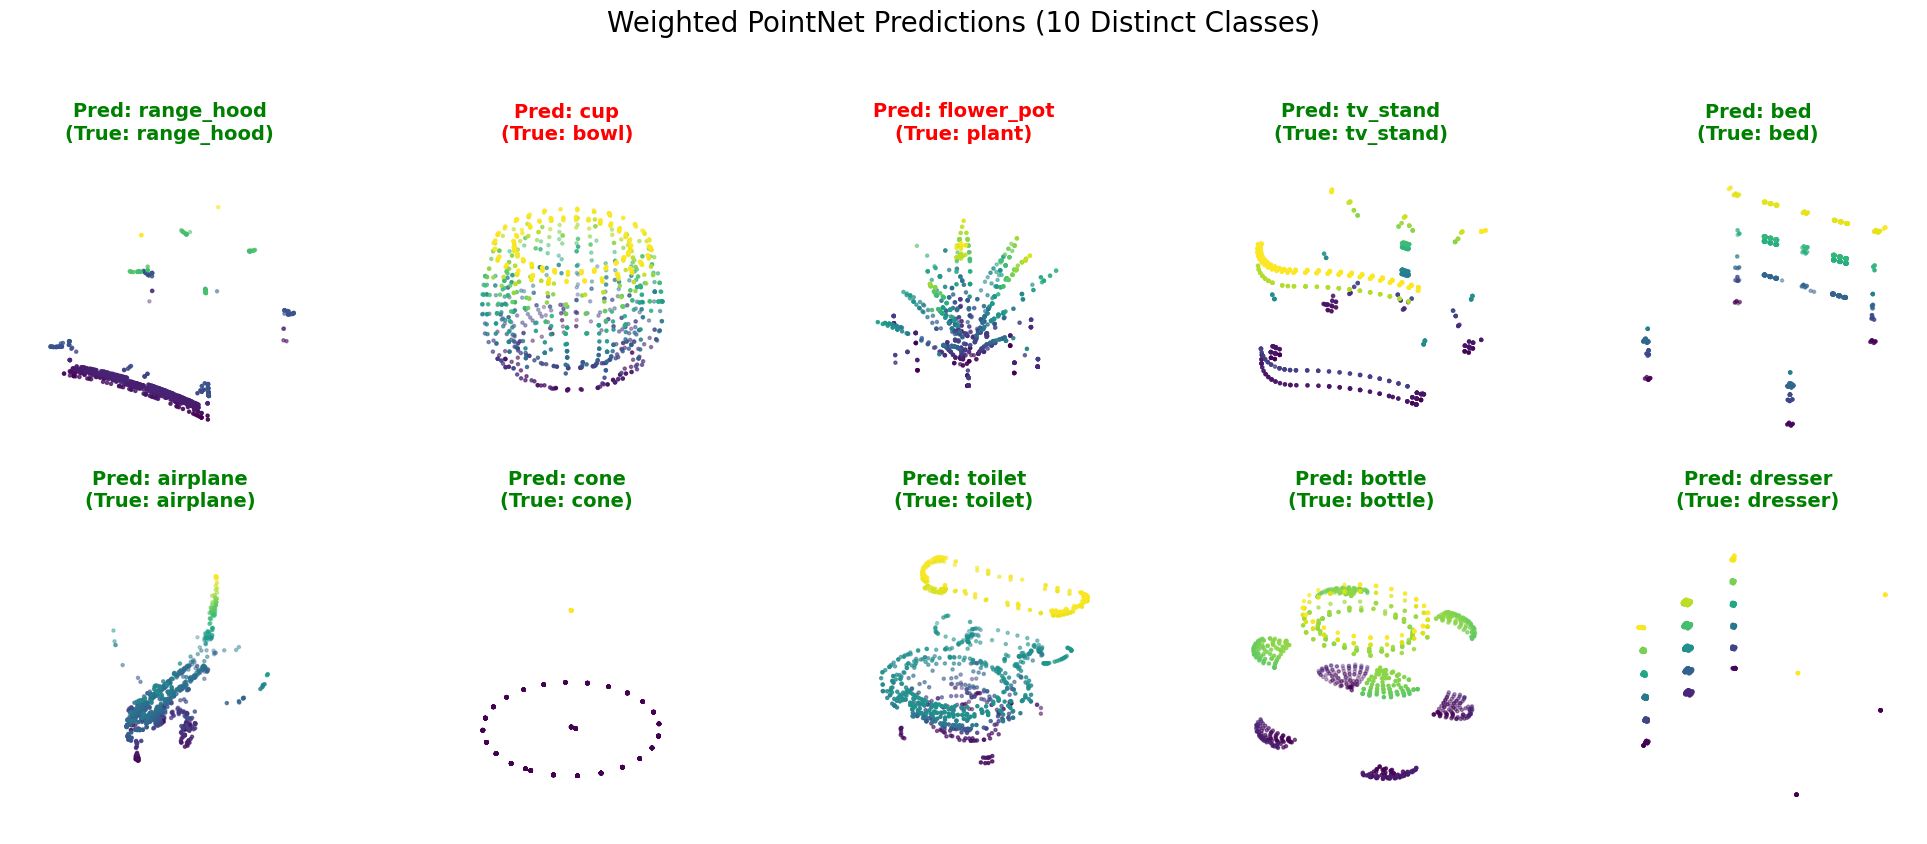

Visualization saved as '10_class_predictions_weighted.png'


In [7]:
all_candidates = []

print("Gathering predictions for visualization...")
with torch.no_grad():
    for points, labels in testloader:
        points_gpu = points.to(device)
        outputs = model(points_gpu)
        _, preds = torch.max(outputs, 1)

        for i in range(points.size(0)):
            all_candidates.append({
                'pc': points[i].cpu().numpy(),
                'pred': preds[i].item(),
                'true': labels[i].item()
            })

random.shuffle(all_candidates)

selected_samples = []
seen_preds = set()

for cand in all_candidates:
    if cand['pred'] not in seen_preds:
        seen_preds.add(cand['pred'])
        selected_samples.append(cand)
    if len(selected_samples) == 10:
        break

fig = plt.figure(figsize=(20, 8))
fig.suptitle("Weighted PointNet Predictions (10 Distinct Classes)", fontsize=20, y=1.05)

for i, sample in enumerate(selected_samples):
    ax = fig.add_subplot(2, 5, i+1, projection='3d')
    pc = sample['pc'].transpose(1, 0)
    ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], s=5, c=pc[:, 2], cmap='viridis')

    pred_name = classes[sample['pred']]
    true_name = classes[sample['true']]

    title_color = 'green' if sample['pred'] == sample['true'] else 'red'
    ax.set_title(f"Pred: {pred_name}\n(True: {true_name})", color=title_color, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

fig.savefig("10_class_predictions_weighted.png", bbox_inches='tight', dpi=300)
print("Visualization saved as '10_class_predictions_weighted.png'")